# Ti64 Statistical Modelling
## Modelling Beta approach curves from literature to produce a beta volume fraction calculator
### Rory Atlasi Barker, Guy Bowker

This notebook can be used to filter beta-approach curves for Ti64 volume fraction measurments from literature.
Change the temperature range, microstructure, strain rate, or other options in the example cells at the bottom to plot the corresponding curves for those conditions.
Functions can be found next to this notebook in `utils.py`.
To add data from a paper, simply create a new file in this repository named after the paper authors as shown containing the data as a `.csv` file.
Then add the papers metadata and relative filepath to the `beta-approach_curves.yaml` file.

In [1]:
# Import libraries and funcs from utils.py

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
from scipy.optimize import curve_fit
import yaml
from yaml.loader import FullLoader
from yaml.loader import SafeLoader
from utils import sort_curve
from utils import curve_filter
from utils import curve_filter_pd
from utils import beta_approach_curve_filter
from utils import beta_approach_curve_plotter

%matplotlib inline

Load `beta-approach_curves.yml` file, read in data for each paper as pandas dataframe, and show all papers:

In [2]:
lit_data = yaml.load(open('beta-approach_curves.yml'), Loader=SafeLoader)

for paper_key in lit_data['Papers'].keys():
    for curve_no, curve_metadata in enumerate(lit_data['Papers'][paper_key]['Curves']):
        
        lit_data['Papers'][paper_key]['Curves'][curve_no]['data'] = pd.read_csv(lit_data['Papers'][paper_key]['Curves'][curve_no]['Curve_location'],
                                     sep=",", skiprows=0)

lit_data['Papers'].keys()

dict_keys(['Sesha_2000', 'Semiatin_2002', 'Tamiri_2005', 'Reddy_2006', 'Motyka_2012', 'Villa_2019', 'Janda_2022'])

Filter out and plot only the desired beta approach curves from the literature data.

Save paper metadata and beta-approach curves to a dictionary `filtered_data`, which can be saved to a `.pkl` file to be plotted alongside other data in a different code. The `filtered_data` dictionary can be easily parsed to plot all the data on the same plot.

In [3]:

# authors_list = ['A. Janda', 'S.L. Semiatin', 'N.S. Reddy']
authors_list = [] # empty list to include all

# year_of_publication = [2022, 2002, 2005, 2006, 2023] 
year_of_publication = [] # empty list to include all

filtered_data = beta_approach_curve_filter(lit_data, authors_list, year_of_publication,
                                           heating_rate='any', Strain_rate='any', heater='any'
                                          )


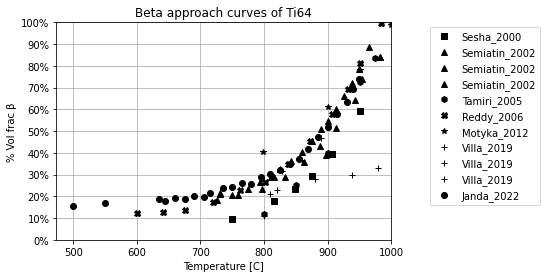

In [4]:
beta_approach_curve_plotter(filtered_data)

pickle.dump(filtered_data, open('beta-approach_curves.pkl', 'wb'))

First, estimate a model relationship between temperature T and volume fraction of beta phase.
An exponential function fits the literature data quite well in most cases.
Here is where the choice of data to include in the previous step becomes important, because some data is more unreliable, has less datapoints, etc.

$\Large{β_{volfrac\%} = a + b^{c(T+d)}}$

$6<a<16$

$1.003<b<1.005$

$1.5<c<2.7$

$-610<d<-155$

In [5]:
def testfunc(T, a, b, c, d):
    """Model exponential function for beta approach curves"""
    return a + (b)**(c*(T+d))

Next, use this model curve to predict/extrapolate between measured datapoints for each curve in the literature.
Plot the model curves for each dataset and see the maximum and minimum bounds for any given temperature or volume fraction of beta.
We can also predict the beta-transus temperature for each dataset.
Note including only papers with high-temperature ranges of beta volume fraction measurments introduces much more uncertainty at lower temperature, and vice versa.



Sesha_2000
a:-1.4421910689235293	b:1.0046580067559885	c: 1.8453899414459507	d: -473.2108260151567

Semiatin_2002
a:6.77739659875367	b:1.0043494251260492	c: 1.9166301569529465	d: -435.54296888638805
Found beta transus!: T=981C
a:10.969512951783704	b:1.0038577209576867	c: 2.3356773660181562	d: -503.48161781470276
a:16.993812414827495	b:1.0050943817949856	c: 2.244597353907761	d: -610.081056321081
Found beta transus!: T=997C

Tamiri_2005
a:-30.195744398601356	b:1.0050043066990884	c: 1.1572881467665996	d: -155.81201181755566
Found beta transus!: T=998C

Reddy_2006
a:6.2870677479286226	b:1.003958728724647	c: 2.014072091301915	d: -411.96034463333336
Found beta transus!: T=982C

Motyka_2012


/mnt/iusers01/jf01/y15576gb/.local/lib/python3.7/site-packages/scipy/optimize/minpack.py:834: OptimizeWarning: Covariance of the parameters could not be estimated
  category=OptimizeWarning)


a:13.311651343521142	b:1.0037759620108022	c: 1.520178257019245	d: -223.5933757293832

Villa_2019
Data for Villa_2019 could not be modelled.
Data for Villa_2019 could not be modelled.
Data for Villa_2019 could not be modelled.

Janda_2022
a:15.380492844891068	b:1.0035341340353376	c: 2.7824624047146314	d: -534.7878113187011
Found beta transus!: T=987C


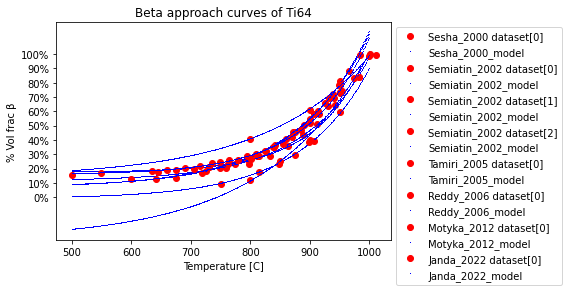

In [6]:

for paper_key in filtered_data['Papers']:
    print(f"\n{paper_key}") ## DEBUG
    filtered_data['Papers'][paper_key]['Curve_models'] = []
    for curve_num, curve in enumerate(filtered_data['Papers'][paper_key]['Curves']):
#         print(filtered_data['Papers'][paper_key]['Curves'][curve_num]) ## DEBUG
        measured_T = curve.iloc[:,0]
        measured_volfracbeta = curve.iloc[:,1]

        try:
            param, param_cov = curve_fit(testfunc, measured_T, measured_volfracbeta)
            print(f"a:{param[0]}\tb:{param[1]}\tc: {param[2]}\td: {param[3]}") ## DEBUG
        except:
            print(f"Data for {paper_key} could not be modelled.")
            continue
        
        T_linspace = np.arange(500,1000, 1)
        fit_volfracbeta = param[0] + param[1]**( param[2]*(T_linspace+param[3]) )
        if 100 in np.around(fit_volfracbeta):
            beta_transus = T_linspace[ np.where(np.around(fit_volfracbeta)==100)[0] ]
            print(f"Found beta transus!: T={beta_transus[0]}C")
        extrapolated_data = {
                "T_linspace": T_linspace,
                "fit_volfracbeta": fit_volfracbeta
               }
        filtered_data['Papers'][paper_key]['Curve_models'].append(pd.DataFrame(extrapolated_data))
        
        modelT = filtered_data['Papers'][paper_key]['Curve_models'][curve_num].iloc[:,0]
        modelbetafrac = filtered_data['Papers'][paper_key]['Curve_models'][curve_num].iloc[:,1]
 
#         plt.figure() # comment out to plot all on one figure
        plt.plot(measured_T, measured_volfracbeta, 'o', color ='red', label =f"{paper_key} dataset[{curve_num}]")
        plt.plot(modelT, modelbetafrac, ',', color ='blue', label =f"{paper_key}_model")
        plt.legend(bbox_to_anchor=[1, 1])
        plt.grid()
        
        plt.title('Beta approach curves of Ti64')
        plt.xlabel(f"Temperature [C]")
        plt.ylabel(f"% Vol frac β")
        plt.yticks([0,10,20,30,40,50,60,70,80,90,100],
                   ["0%","10%","20%","30%","40%","50%","60%","70%","80%","90%","100%"])
        

To get a definitive answer to the question "what is the beta volume fraction at temperature $X$?" the model curves need to be combined.
One model beta approach curve weighted by the contributions of many measured beta approach curves is the most reliable to answer this question.
We have `T` and `betavolfrac` values from $500C$ to $1000C$ in $1C$ steps for each dataset -
we can mean over these values to get a mean beta approach curve:

([<matplotlib.axis.YTick at 0x7fb8208a6898>,
 [Text(0, 0, '0%'),
  Text(0, 10, '10%'),
  Text(0, 20, '20%'),
  Text(0, 30, '30%'),
  Text(0, 40, '40%'),
  Text(0, 50, '50%'),
  Text(0, 60, '60%'),
  Text(0, 70, '70%'),
  Text(0, 80, '80%'),
  Text(0, 90, '90%'),
  Text(0, 100, '100%')])

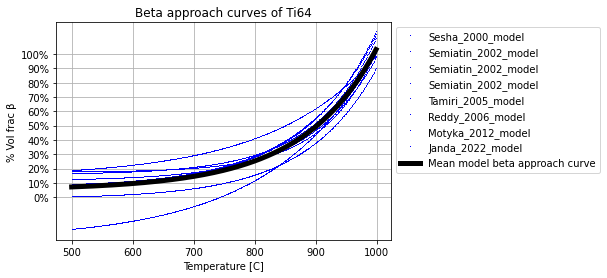

In [7]:

list_of_dataframes = []
for paper_key in filtered_data['Papers']:
    for curve_num, curve in enumerate(filtered_data['Papers'][paper_key]['Curve_models']):
        measured_T = curve.iloc[:,0]
        measured_volfracbeta = curve.iloc[:,1]
        modelT = filtered_data['Papers'][paper_key]['Curve_models'][curve_num].iloc[:,0]
        modelbetafrac = filtered_data['Papers'][paper_key]['Curve_models'][curve_num].iloc[:,1]
        plt.plot(modelT, modelbetafrac, ',', color ='blue', label =f"{paper_key}_model")
        
        list_of_dataframes.append(curve)

# mean betavolfrac coloumn over all dataframes
mean_rows = []
for rows in zip(*[df.iloc[:, 1] for df in list_of_dataframes]):
    mean_row = sum(rows) / len(rows)
    mean_rows.append(mean_row)
# Create a DataFrame from the calculated mean rows of betavolfrac

mean_T = filtered_data['Papers']['Janda_2022']['Curve_models'][0].iloc[:,0]
mean_beta_volfrac = pd.DataFrame(mean_rows)
mean_betaapproach_curve = pd.concat([mean_T, mean_beta_volfrac], axis=1)

plt.plot(mean_betaapproach_curve.iloc[:,0], mean_betaapproach_curve.iloc[:,1],
         color='k', linewidth=5,
         label='Mean model beta approach curve')
plt.legend(bbox_to_anchor=[1, 1])
plt.grid()
plt.title('Beta approach curves of Ti64')
plt.xlabel(f"Temperature [C]")
plt.ylabel(f"% Vol frac β")
plt.yticks([0,10,20,30,40,50,60,70,80,90,100],
           ["0%","10%","20%","30%","40%","50%","60%","70%","80%","90%","100%"])

With this mean curve of models of all datasets, we can return an answer for beta volume fraction \% given an input temperature T:


In [8]:
input_T = 950

mean_model_T = mean_betaapproach_curve.iloc[:,0]
mean_model_betavolfrac = mean_betaapproach_curve.iloc[:,1]

if 100 in np.around(mean_model_betavolfrac):
    beta_transus = mean_model_T[ np.where(np.around(mean_model_betavolfrac)==100)[0] ]
    print(f"\nBeta Transus: T={beta_transus.iloc[0]}C")

T_idx = np.where(round(mean_betaapproach_curve.iloc[:,0])==input_T)[0]
beta_volfrac = mean_betaapproach_curve.iloc[T_idx, 1].iloc[0]
print(f"\nBeta volume fraction at T={input_T} is {beta_volfrac}%")


Beta Transus: T=995C

Beta volume fraction at T=950 is 70.92660046180875%
